# 03d — Six-Basis Anticyclone Decomposition (Blocking, 300 hPa)

Applies the six-basis PV tendency projection to an **anticyclonic blocking event**
tracked by TempestExtremes (Z500-based).

- Track selected from the **blocking anticyclone catalogue**
- PV decomposition at **300 hPa** — anticyclonic PV anomaly is **naturally negative**
  so `mask="< -2e-7"` works directly without any sign flip
- Storm-following centres come from **PRP-high blockstats** (hourly centroids)
- ERA5 PV is reloaded from monthly files

Sections: sample basis visualisation (including a dedicated PV-tendency
temporal comparison), 2-D component maps, lifecycle time curves,
Cartopy track comparison, animated GIF, and budget closure.

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob, os

from pvtend import (compute_orthogonal_basis, project_field, R_EARTH,
                    lerp_fields, ddt)
from pvtend.plotting import plot_coefficient_curves
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.decomposition.basis import (PRENORM_PHI1, PRENORM_PHI2,
                                         PRENORM_PHI3, PRENORM_PHI4,
                                         PRENORM_PHI5, PRENORM_PHI6)
from pvtend.derivatives import ddx, ddy

# ── Constants ──────────────────────────────
LEVEL_PA   = 300.0           # hPa — upper troposphere for blocking
SMOOTH_DEG = 3.0             # Gaussian smoothing half-width (degrees)
GRID_DEG   = 1.5             # ERA5 grid spacing (degrees)
HALF_LAT   = 15.0            # patch half-extent latitude (degrees)
HALF_LON   = 25.0            # patch half-extent longitude (degrees)
# No FLIP needed — anticyclonic PV anomaly at 300 hPa is naturally negative,
# so mask="< -2e-7" directly isolates the anticyclone region.

# Index-based half-widths for fixed-shape patch extraction
HALF_LAT_IDX = round(HALF_LAT / GRID_DEG)   # 10
HALF_LON_IDX = round(HALF_LON / GRID_DEG)   # 17

ERA_DIR  = "/net/flood/data2/users/x_yan/era"
CLIM_DIR = "/net/flood/data2/users/x_yan/era/clim"
NPZ_BASE = "/net/flood/data2/users/x_yan/composite_blocking_tempest/peak"
CSV_PATH = "/net/flood/data2/users/x_yan/pvtend/docs/_static/ERA5_TempestExtremes_z500_anticyclone_blocking.csv"
GIF_PATH = "/net/flood/data2/users/x_yan/pvtend/docs/_static/blocking_ac_lifecycle_demo.gif"
BLOCKSTATS_PATH = "/net/flood/data2/users/x_yan/tracking_tmpp_prp_high/ERA5_blockstats.txt"

MONTH_NAMES = {1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",
               7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}

# dh range available from NPZ composites
DH_MIN, DH_MAX = -13, 12  # NPZ directories exist for dh=-13 to dh=+12

In [2]:
# ── Load blocking anticyclone catalogue and pick a track ──────────────
df_all = pd.read_csv(CSV_PATH)
df_peak = df_all[df_all["type"] == "peak"].reset_index(drop=True)

# Pick a random track (deterministic seed)
rng = np.random.RandomState(42)
chosen_idx = rng.randint(0, len(df_peak))
row_peak = df_peak.iloc[chosen_idx]
TRACK_ID = int(row_peak["track_id"])
peak_ts = pd.Timestamp(row_peak["timestamp"])
peak_ts_str = peak_ts.strftime("%Y%m%d%H")

print(f"Selected track {TRACK_ID}  (peak: {peak_ts})")
print(f"  Peak lat={row_peak['lat']:.1f}  lon={row_peak['lon180']:.1f}")

# ── Load blockstats for hourly centre positions ──────────────
# Blockstats columns (tab-separated, 1 header row):
#   track_id | hour_idx | "timestamp" | lat | lon(0-360) | area
bs = pd.read_csv(BLOCKSTATS_PATH, sep="\t", header=None, skiprows=1,
                  names=["track_id", "hour_idx", "timestamp", "lat", "lon", "area"])
bs["timestamp"] = bs["timestamp"].str.strip('"')
bs["timestamp"] = pd.to_datetime(bs["timestamp"])

# Convert blockstats lon from 0-360 to -180/180
bs["lon180"] = np.where(bs["lon"] > 180, bs["lon"] - 360, bs["lon"])

# ── Match CSV track to blockstats track by proximity at peak time ──────
peak_rows = bs[bs["timestamp"] == peak_ts]

if len(peak_rows) == 0:
    raise ValueError(f"No blockstats rows at peak timestamp {peak_ts}")

# Compute great-circle-like distance (simplified spherical) to CSV peak
csv_lat = row_peak["lat"]
csv_lon = row_peak["lon180"]
cos_lat_ref = np.cos(np.radians(csv_lat))
dists = np.sqrt(
    (peak_rows["lat"].values - csv_lat) ** 2
    + ((peak_rows["lon180"].values - csv_lon) * cos_lat_ref) ** 2
)
best_idx = np.argmin(dists)
BS_TRACK_ID = int(peak_rows.iloc[best_idx]["track_id"])
match_dist = dists[best_idx]

print(f"  Matched blockstats track {BS_TRACK_ID}  (dist = {match_dist:.1f} deg)")
print(f"  Blockstats peak lat={peak_rows.iloc[best_idx]['lat']:.1f}"
      f"  lon={peak_rows.iloc[best_idx]['lon180']:.1f}")

# ── Extract ±13h window from blockstats track, centred on peak ──────
bs_track = bs[bs["track_id"] == BS_TRACK_ID].sort_values("timestamp").reset_index(drop=True)

# Find the row closest to peak_ts
peak_match_idx = (bs_track["timestamp"] - peak_ts).abs().argmin()

# Extract ±13 hour window
i_start = max(0, peak_match_idx - 13)
i_end = min(len(bs_track), peak_match_idx + 13)  # exclusive upper bound
bs_window = bs_track.iloc[i_start:i_end].reset_index(drop=True)

# Compute dh offsets relative to peak
dh_vals = np.array([
    int((t - peak_ts).total_seconds() / 3600)
    for t in bs_window["timestamp"]
])
lats_hourly = bs_window["lat"].values.astype(float)
lons_hourly = bs_window["lon180"].values.astype(float)
times_hourly = bs_window["timestamp"].values
N = len(dh_vals)

# Tracked speed via centred differences on hourly centres (m/s)
cos_lat = np.cos(np.radians(lats_hourly))
dlat = np.gradient(lats_hourly)                        # deg / hour
dlon = np.gradient(lons_hourly)                        # deg / hour
vx_track = dlon * (np.pi / 180.0) * R_EARTH * cos_lat / 3600.0  # m/s
vy_track = dlat * (np.pi / 180.0) * R_EARTH / 3600.0            # m/s

# Onset / decay info from CSV
row_onset = df_all[(df_all["track_id"] == TRACK_ID) & (df_all["type"] == "onset")]
row_decay = df_all[(df_all["track_id"] == TRACK_ID) & (df_all["type"] == "decay")]

print(f"\nTrack {TRACK_ID}: {N} hourly points  (dh = {dh_vals[0]:+d} to {dh_vals[-1]:+d})")
print(f"  Period : {times_hourly[0]} -> {times_hourly[-1]}")
print(f"  Lat    : {lats_hourly.min():.1f} -> {lats_hourly.max():.1f} deg")
print(f"  Lon    : {lons_hourly.min():.1f} -> {lons_hourly.max():.1f} deg")
print(f"  <vx>   : {vx_track.mean():.1f} m/s")
print(f"  <vy>   : {vy_track.mean():.1f} m/s")
if len(row_onset):
    print(f"  Onset  : {row_onset.iloc[0]['timestamp']}")
if len(row_decay):
    print(f"  Decay  : {row_decay.iloc[0]['timestamp']}")

Selected track 1237  (peak: 2018-02-19 10:00:00)
  Peak lat=65.1  lon=-155.3
  Matched blockstats track 1935  (dist = 16.9 deg)
  Blockstats peak lat=65.9  lon=-115.3

Track 1237: 26 hourly points  (dh = -13 to +12)
  Period : 2018-02-18T21:00:00.000000 -> 2018-02-19T22:00:00.000000
  Lat    : 65.4 -> 66.2 deg
  Lon    : -119.0 -> -110.6 deg
  <vx>   : 3.6 m/s
  <vy>   : -0.3 m/s
  Onset  : 2018-02-10 20:00:00
  Decay  : 2018-03-13 23:00:00


## 1  ERA5 data-loading helpers

In [3]:
# Caches to avoid re-opening files every timestep
_ds_cache = {}

def _open_era(var, year, month):
    key = (var, year, month)
    if key not in _ds_cache:
        path = f"{ERA_DIR}/era5_{var}_{year}_{month:02d}.nc"
        _ds_cache[key] = xr.open_dataset(path)
    return _ds_cache[key]

def _open_clim(var, month):
    key = ("clim", var, month)
    if key not in _ds_cache:
        mname = MONTH_NAMES[month]
        path = f"{CLIM_DIR}/era5_hourly_clim_1990-2020_{mname}_{var}.nc"
        _ds_cache[key] = xr.open_dataset(path)
    return _ds_cache[key]


def load_era5_field(var, dt64, level_hpa=LEVEL_PA):
    """Load a single 2-D field (lat, lon) from monthly ERA5 file."""
    ts = pd.Timestamp(dt64)
    ds = _open_era(var, ts.year, ts.month)
    da = ds[var].sel(valid_time=str(ts), pressure_level=level_hpa)
    return da.values, ds.latitude.values, ds.longitude.values


def load_clim_field(var, month, day, hour, level_hpa=LEVEL_PA):
    """Load climatological field (lat, lon) matching month/day/hour."""
    dc = _open_clim(var, month)
    da = dc[var].sel(month=month, day=day, hour=hour,
                     pressure_level=level_hpa)
    return da.values  # same lat/lon grid as ERA5


def extract_patch(field2d, lat1d, lon1d, clat, clon,
                  hlat_idx=HALF_LAT_IDX, hlon_idx=HALF_LON_IDX):
    """Extract a fixed-shape patch using index-based slicing.

    Snaps (clat, clon) to the nearest grid point, then takes
    ±hlat_idx / ±hlon_idx grid points.  Always returns the same
    shape (2*hlat_idx+1, 2*hlon_idx+1) regardless of exact centre.
    """
    ilat = int(np.abs(lat1d - clat).argmin())
    ilon = int(np.abs(lon1d - clon).argmin())

    # lat may be descending (90->0) in ERA5 -> work in ascending order
    lat_desc = lat1d[0] > lat1d[-1]
    if lat_desc:
        lat_asc = lat1d[::-1]
        field_asc = field2d[::-1]
        ilat_asc = len(lat1d) - 1 - ilat
    else:
        lat_asc = lat1d
        field_asc = field2d
        ilat_asc = ilat

    i0_lat = ilat_asc - hlat_idx
    i1_lat = ilat_asc + hlat_idx + 1
    i0_lon = ilon - hlon_idx
    i1_lon = ilon + hlon_idx + 1

    lat_sub = lat_asc[i0_lat:i1_lat]
    lon_sub = lon1d[i0_lon:i1_lon]
    patch = field_asc[i0_lat:i1_lat, i0_lon:i1_lon]

    x_rel = lon_sub - clon
    y_rel = lat_sub - clat
    return patch, x_rel, y_rel, lat_sub, lon_sub


def compute_gradients(pv_patch, lat_sub, x_rel, y_rel):
    """Compute zonal/meridional PV gradients on a patch in SI."""
    dy = np.abs(y_rel[1] - y_rel[0]) * (np.pi / 180.0) * R_EARTH
    dx_arr = (np.abs(x_rel[1] - x_rel[0]) * (np.pi / 180.0)
              * R_EARTH * np.cos(np.radians(lat_sub)))
    pv_dx = ddx(pv_patch, dx_arr, periodic=False)
    pv_dy = ddy(pv_patch, dy)
    return pv_dx, pv_dy


# ── PV contour level for 300 hPa anticyclone ──
# Anticyclonic PV anomaly is negative; use a negative threshold
PV_CONTOUR_LEVEL = [-1.5e-6]   # -1.5 PVU

from matplotlib.path import Path as MplPath

def _find_center_contour_segs(x, y, field, levels, center):
    """Find contour segments enclosing *center* with ±1 deg fallback."""
    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(x, y, field, levels=levels)
    plt.close(fig_tmp)

    # Pass 1: exact center
    for level_segs in cs.allsegs:
        for seg in level_segs:
            if seg.shape[0] < 4:
                continue
            mpl_path = MplPath(seg)
            if mpl_path.contains_point(center):
                yield seg

    # Pass 2: ±1 deg box around center
    cx, cy = center
    box_pts = [(cx - 1, cy - 1), (cx + 1, cy - 1),
               (cx + 1, cy + 1), (cx - 1, cy + 1)]
    for level_segs in cs.allsegs:
        for seg in level_segs:
            if seg.shape[0] < 4:
                continue
            mpl_path = MplPath(seg)
            if any(mpl_path.contains_point(p) for p in box_pts):
                yield seg


def contour_enclosing_center(ax, x, y, field, levels, center=(0, 0),
                             transform=None, **kwargs):
    """Draw only closed contours whose path encloses `center`."""
    artists = []
    for seg in _find_center_contour_segs(x, y, field, levels, center):
        plot_kw = dict(kwargs)
        if transform is not None:
            plot_kw["transform"] = transform
        ln, = ax.plot(seg[:, 0], seg[:, 1], **plot_kw)
        artists.append(ln)
    return artists


def build_center_mask(x2d, y2d, field, levels, center=(0, 0)):
    """Boolean mask True inside all centre-enclosing contours."""
    mask = np.zeros(field.shape, dtype=bool)
    for seg in _find_center_contour_segs(x2d, y2d, field, levels, center):
        mpl_path = MplPath(seg)
        pts = np.column_stack([x2d.ravel(), y2d.ravel()])
        mask |= mpl_path.contains_points(pts).reshape(field.shape)
    return mask


print(f"Helpers defined.  Patch shape = ({2*HALF_LAT_IDX+1}, {2*HALF_LON_IDX+1})")

Helpers defined.  Patch shape = (21, 35)


## 2  Sample timestep — basis construction

In [4]:
# Pick a sample timestep near the middle of the track
# We need t-1h and t+1h, so skip the first and last entries
SAMPLE_IDX = N // 2
t_s = times_hourly[SAMPLE_IDX]
ts_s = pd.Timestamp(t_s)
clat_s = lats_hourly[SAMPLE_IDX]
clon_s = lons_hourly[SAMPLE_IDX]

# Storm-following centres for t-1h and t+1h
clat_m = lats_hourly[SAMPLE_IDX - 1]
clon_m = lons_hourly[SAMPLE_IDX - 1]
clat_p = lats_hourly[SAMPLE_IDX + 1]
clon_p = lons_hourly[SAMPLE_IDX + 1]

# Also need t-2h for the PV tendency visualization
clat_mm = lats_hourly[SAMPLE_IDX - 2]
clon_mm = lons_hourly[SAMPLE_IDX - 2]

print(f"Sample timestep #{SAMPLE_IDX} (dh={dh_vals[SAMPLE_IDX]:+d}): {ts_s}")
print(f"  centre = ({clat_s:.1f} N, {clon_s:.1f} E)")
print(f"  t-1h centre: ({clat_m:.1f} N, {clon_m:.1f} E)")
print(f"  t+1h centre: ({clat_p:.1f} N, {clon_p:.1f} E)")
print(f"  t-2h centre: ({clat_mm:.1f} N, {clon_mm:.1f} E)")

# Load PV at t-2h, t-1h, t, t+1h
pv_mm, lat1d, lon1d = load_era5_field("pv", t_s - np.timedelta64(2, "h"))
pv_m, _, _           = load_era5_field("pv", t_s - np.timedelta64(1, "h"))
pv_0, _, _           = load_era5_field("pv", t_s)
pv_p, _, _           = load_era5_field("pv", t_s + np.timedelta64(1, "h"))

# Climatology at each offset time
ts_mm = pd.Timestamp(t_s - np.timedelta64(2, "h"))
ts_m  = pd.Timestamp(t_s - np.timedelta64(1, "h"))
ts_p  = pd.Timestamp(t_s + np.timedelta64(1, "h"))
pv_bar_0  = load_clim_field("pv", ts_s.month, ts_s.day, ts_s.hour)
pv_bar_m  = load_clim_field("pv", ts_m.month, ts_m.day, ts_m.hour)
pv_bar_mm = load_clim_field("pv", ts_mm.month, ts_mm.day, ts_mm.hour)
pv_bar_p  = load_clim_field("pv", ts_p.month, ts_p.day, ts_p.hour)

# Extract patches -- STORM-FOLLOWING: each offset on its own tracked centre
pv_0_p, x_rel, y_rel, lat_sub, lon_sub = extract_patch(pv_0, lat1d, lon1d, clat_s, clon_s)
pv_m_p, _, _, _, _ = extract_patch(pv_m, lat1d, lon1d, clat_m, clon_m)
pv_p_p, _, _, _, _ = extract_patch(pv_p, lat1d, lon1d, clat_p, clon_p)
pv_mm_p, _, _, _, _ = extract_patch(pv_mm, lat1d, lon1d, clat_mm, clon_mm)
bar_0_p, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_s, clon_s)
bar_m_p, *_ = extract_patch(pv_bar_m, lat1d, lon1d, clat_m, clon_m)
bar_mm_p, *_ = extract_patch(pv_bar_mm, lat1d, lon1d, clat_mm, clon_mm)
bar_p_p, *_ = extract_patch(pv_bar_p, lat1d, lon1d, clat_p, clon_p)

# PV anomaly in storm-relative coords
pv_anom_0 = pv_0_p - bar_0_p
pv_anom_m = pv_m_p - bar_m_p

# Centred finite-difference PV tendency [PVU/s] using pvtend.ddt
pv_stack = np.stack([pv_m_p, pv_0_p, pv_p_p], axis=0)   # (3, nlat, nlon)
pv_dt_raw = ddt(pv_stack, dt_s=3600.0)[1]                # centre timestep

# Gradients at t and t-1h  (NO FLIP — anticyclone anomaly is naturally negative)
pv_dx_0, pv_dy_0 = compute_gradients(pv_anom_0, lat_sub, x_rel, y_rel)
pv_dx_m, pv_dy_m = compute_gradients(pv_anom_m, lat_sub, x_rel, y_rel)

X_rel, Y_rel = np.meshgrid(x_rel, y_rel)

print(f"\n  Patch shape : {pv_0_p.shape}")
print(f"  PV anom max : {pv_anom_0.max():.3e} PVU")
print(f"  PV anom min : {pv_anom_0.min():.3e} PVU  <- should be negative for anticyclone")

Sample timestep #13 (dh=+0): 2018-02-19 10:00:00
  centre = (65.9 N, -115.3 E)
  t-1h centre: (65.6 N, -116.1 E)
  t+1h centre: (66.0 N, -114.1 E)
  t-2h centre: (65.5 N, -117.0 E)

  Patch shape : (21, 35)
  PV anom max : 4.579e-06 PVU
  PV anom min : -3.983e-06 PVU  <- should be negative for anticyclone


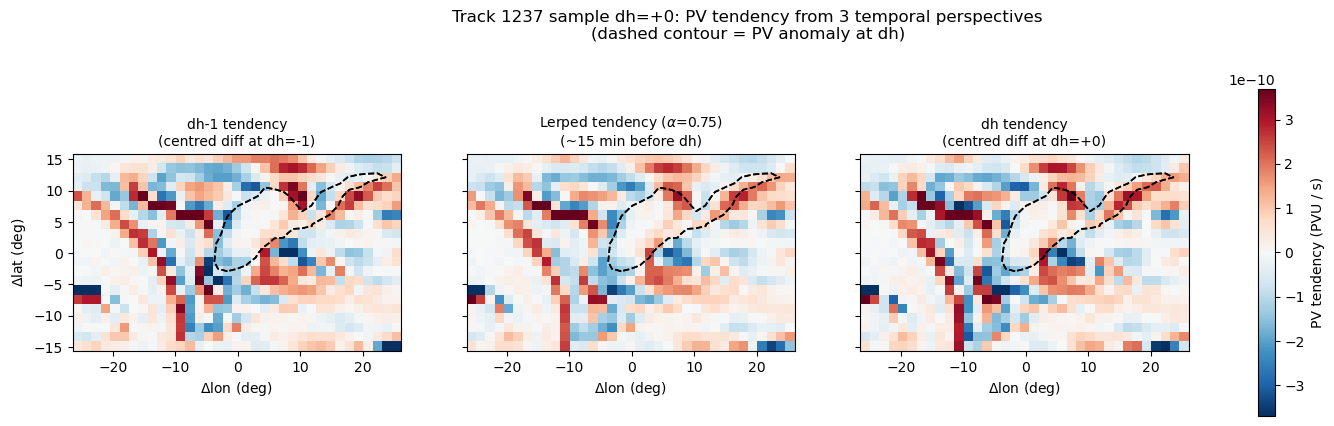

MAE(dh-1 vs dh):   1.026e-10
MAE(lerp vs dh):   2.566e-11
Lerp reduces dh-1 error by 75.0%


In [5]:
# ── Visualise PV tendency from 3 temporal perspectives in the dh patch ──
#
# 1. dh-1 pv_dt: centred diff at (dh-1) using [dh-2, dh-1, dh], extracted
#    onto the dh-1 centre but then viewed on the *dh patch grid*
# 2. Lerped pv_dt: alpha=0.75 blend of dh-1 and dh tendencies (~15 min before dh)
# 3. dh pv_dt: centred diff at dh using [dh-1, dh, dh+1]
#
# This shows how the tendency field evolves and how the temporal interpolation
# captures the transition.

# Compute dh-1 tendency: centred diff using [dh-2, dh-1, dh]
pv_stack_m = np.stack([pv_mm_p, pv_m_p, pv_0_p], axis=0)
pv_dt_m_raw = ddt(pv_stack_m, dt_s=3600.0)[1]  # tendency at dh-1

# dh tendency (already computed above as pv_dt_raw)
pv_dt_0_raw = pv_dt_raw

# Lerp the two tendencies at alpha=0.75
pv_dt_lerp = lerp_fields(
    {"pv_anom": pv_dt_m_raw},
    {"pv_anom": pv_dt_0_raw},
    alpha=0.75,
    keys=("pv_anom",),
)["pv_anom"]

# ── 3-panel comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
vmax = np.nanpercentile(np.abs(pv_dt_0_raw), 98)

fields_dt = [pv_dt_m_raw, pv_dt_lerp, pv_dt_0_raw]
titles_dt = [
    f"dh-1 tendency\n(centred diff at dh={dh_vals[SAMPLE_IDX]-1:+d})",
    r"Lerped tendency ($\alpha$=0.75)" + "\n(~15 min before dh)",
    f"dh tendency\n(centred diff at dh={dh_vals[SAMPLE_IDX]:+d})",
]

for ax, fld, ttl in zip(axes, fields_dt, titles_dt):
    im = ax.pcolormesh(X_rel, Y_rel, fld, cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, shading="auto")
    # Overlay PV anomaly contour at dh
    contour_enclosing_center(ax, x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                             color="k", linewidth=1.2, linestyle="--")
    ax.set_title(ttl, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\Delta$lon (deg)")
axes[0].set_ylabel(r"$\Delta$lat (deg)")

fig.colorbar(im, ax=axes, label="PV tendency (PVU / s)", shrink=0.85)
fig.suptitle(f"Track {TRACK_ID} sample dh={dh_vals[SAMPLE_IDX]:+d}: "
             "PV tendency from 3 temporal perspectives\n"
             "(dashed contour = PV anomaly at dh)",
             fontsize=12)
# plt.tight_layout()
plt.show()

# Quick difference check
diff_m_0 = np.nanmean(np.abs(pv_dt_m_raw - pv_dt_0_raw))
diff_lerp_0 = np.nanmean(np.abs(pv_dt_lerp - pv_dt_0_raw))
print(f"MAE(dh-1 vs dh):   {diff_m_0:.3e}")
print(f"MAE(lerp vs dh):   {diff_lerp_0:.3e}")
print(f"Lerp reduces dh-1 error by {(1 - diff_lerp_0/diff_m_0)*100:.1f}%")

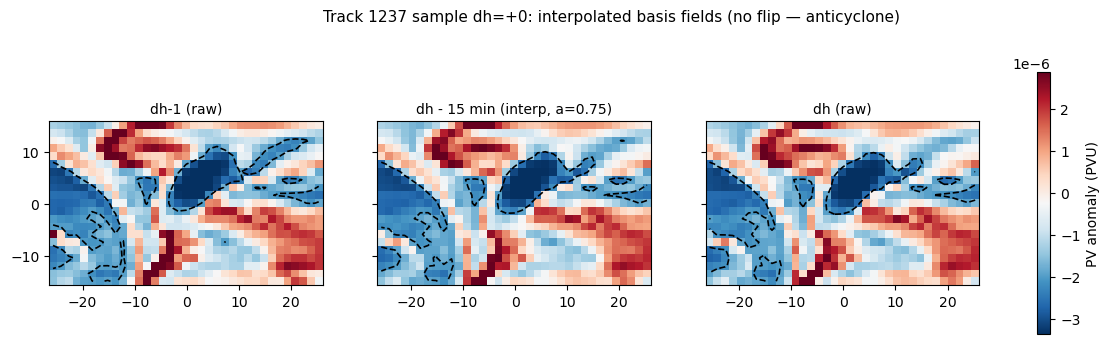

In [6]:
# 3-panel comparison: PV anom at t-1h | lerped t-15min | PV anom at t
interp = lerp_fields(
    {"pv_anom": pv_anom_m, "pv_dx": pv_dx_m, "pv_dy": pv_dy_m},
    {"pv_anom": pv_anom_0, "pv_dx": pv_dx_0, "pv_dy": pv_dy_0},
    alpha=0.75,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
vmin, vmax = np.nanpercentile(pv_anom_0, [2, 98])

titles = ["dh-1 (raw)", "dh - 15 min (interp, a=0.75)", "dh (raw)"]
fields = [pv_anom_m, interp["pv_anom"], pv_anom_0]

for ax, fld, ttl in zip(axes, fields, titles):
    im = ax.pcolormesh(X_rel, Y_rel, fld, cmap="RdBu_r",
                       vmin=vmin, vmax=vmax, shading="auto")
    ax.contour(X_rel, Y_rel, fld, levels=[np.nanmin(fld) * 0.5],
               colors="k", linewidths=1.2)
    ax.set_title(ttl, fontsize=10)
    ax.set_aspect("equal")

fig.colorbar(im, ax=axes, label="PV anomaly (PVU)", shrink=0.85)
fig.suptitle(f"Track {TRACK_ID} sample dh={dh_vals[SAMPLE_IDX]:+d}: "
             "interpolated basis fields (no flip — anticyclone)",
             fontsize=11)
plt.show()

In [7]:
# Build basis directly from dh=0 fields (no temporal interpolation)
basis = compute_orthogonal_basis(
    pv_anom=pv_anom_0,
    pv_dx=pv_dx_0,
    pv_dy=pv_dy_0,
    x_rel=x_rel,
    y_rel=y_rel,
    mask="< -2e-7",
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG,
    grid_spacing=GRID_DEG,
)
print("Basis norms :", {k: f"{v:.4e}" for k, v in basis.norms.items()})
print("Scale factors:", basis.scale_factors)

Basis norms : {'beta': '1.1644e+03', 'ax': '2.2396e+04', 'ay': '4.9323e+03', 'gamma': '1.9915e+05'}
Scale factors: {'beta': 1000000.0, 'ax': 1000000000000.0, 'ay': 1000000000000.0, 'gamma': 1e+18}


## 3  Visualise the six basis fields

In [ ]:
# 6-basis visualisation with centre-only PV contour
from matplotlib.colors import TwoSlopeNorm

fields_b = [basis.phi_int, basis.phi_dx, basis.phi_dy,
            basis.phi_def, basis.phi_strain, basis.phi_lap]
titles_b = [
    r"$\Phi_1$: PV anomaly $q'$  (15-min interp)",
    r"$\Phi_2$: $\partial q / \partial x$",
    r"$\Phi_3$: $\partial q / \partial y$",
    r"$\Phi_4$: $\partial^2 q / \partial x \partial y$",
]

# Build a mask for the center PV anomaly region
# Anticyclone has NEGATIVE PV anomaly → contour at PV_CONTOUR_LEVEL (negative)
X_g, Y_g = np.meshgrid(x_rel, y_rel)
center_mask = build_center_mask(X_g, Y_g, pv_anom_0, PV_CONTOUR_LEVEL, center=(0, 0))
print(f"Centre PV-anom mask: {center_mask.sum()} pixels out of {center_mask.size}")

fig, axes = plt.subplots(2, 3, figsize=(16, 12))

for ax, fld, ttl in zip(axes.flat, fields_b, titles_b):
    # vmin/vmax from ONLY the centre-contour region
    if center_mask.any():
        vmax_c = np.nanmax(np.abs(fld[center_mask]))
    else:
        vmax_c = np.nanmax(np.abs(fld))
    if vmax_c < 1e-30:
        vmax_c = 1.0
    norm = TwoSlopeNorm(vmin=-vmax_c, vcenter=0.0, vmax=vmax_c)
    im = ax.imshow(
        fld, origin="lower", cmap="coolwarm", norm=norm,
        extent=[x_rel.min(), x_rel.max(), y_rel.min(), y_rel.max()],
        aspect="equal",
    )
    # Centre-only PV anomaly contour
    contour_enclosing_center(ax, x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                             color="k", linewidth=1.2, linestyle="--")
    ax.set_title(ttl, fontsize=11)
    ax.set_xlabel(r"$\Delta$lon (deg)")
    ax.set_ylabel(r"$\Delta$lat (deg)")
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

fig.suptitle("Orthogonal bases (anticyclone, 300 hPa, no flip)\n"
             "vmin/vmax from centre PV-anom region only; dashed = centre contour",
             fontsize=13, y=1.04)
fig.tight_layout()
plt.show()

# Dipole diagnostic: does Phi1 have sign changes inside the centre mask?
if center_mask.any():
    phi1_center = basis.phi_int[center_mask]
    has_pos = np.any(phi1_center > 0)
    has_neg = np.any(phi1_center < 0)
    print(f"\nPhi1 in centre region: min={phi1_center.min():.4e}, max={phi1_center.max():.4e}")
    if has_pos and has_neg:
        print("WARNING: DIPOLE detected in Phi1 inside centre contour")
    else:
        sign = "positive" if has_pos else "negative"
        print(f"OK: Phi1 is purely {sign} inside centre contour — no dipole from 15-min interp")

## 4  Project PV tendency onto basis

In [ ]:
pv_dt_smooth = gaussian_smooth_nan(pv_dt_raw, smoothing_deg=SMOOTH_DEG,
                                    grid_spacing=GRID_DEG)
proj = project_field(pv_dt_smooth, basis)

print(f"beta (intensification)    = {proj['beta']:.3e}  s-1")
print(f"ax   (zonal propagation)  = {proj['ax']:.3f}  m/s")
print(f"ay   (merid. propagation) = {proj['ay']:.3f}  m/s")
print(f"gamma1 (shear def.)       = {proj['gamma1']:.3e}  m2 s-1")
print(f"gamma2 (strain def.)      = {proj['gamma2']:.3e}  m2 s-1")
print(f"sigma  (Laplacian)        = {proj['sigma']:.3e}  m2 s-1")
print(f"RMSE / max|dq/dt|         = {proj['rmse'] / (np.nanmax(np.abs(pv_dt_smooth)) + 1e-30):.3f}")

## 5  2-D component maps

In [ ]:
# Reconstruct individual components
beta_comp  = proj["beta_raw"]  * basis.phi_int
ax_comp    = -proj["ax_raw"]   * basis.phi_dx
ay_comp    = -proj["ay_raw"]   * basis.phi_dy
gamma1_comp = -proj["gamma1_raw"] * basis.phi_def
gamma2_comp = -proj["gamma2_raw"] * basis.phi_strain
sigma_comp  = proj["sigma_raw"]  * basis.phi_lap

vmax_prop = max(np.nanpercentile(np.abs(ax_comp), 95),
                np.nanpercentile(np.abs(ay_comp), 95))
vmax_id   = max(np.nanpercentile(np.abs(beta_comp), 95),
                np.nanpercentile(np.abs(gamma1_comp), 95))
levels_prop = np.linspace(-vmax_prop, vmax_prop, 20)
levels_id   = np.linspace(-vmax_id,   vmax_id,   20)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (comp, title) in enumerate([
    (ax_comp,  "Zonal prop. (-ax Phi2)"),
    (ay_comp,  "Merid. prop. (-ay Phi3)"),
]):
    a = axes[0, i]
    cf_prop = a.contourf(x_rel, y_rel, comp, levels=levels_prop,
                         cmap="coolwarm", extend="both")
    contour_enclosing_center(a, x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                             color="k", linewidth=1.0, linestyle="--")
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_prop, ax=axes[0, :].tolist(), shrink=0.8, label="PVU / s")

for i, (comp, title) in enumerate([
    (beta_comp,  "Intensification (beta Phi1)"),
    (gamma1_comp, "Shear def. (-gamma1 Phi4)"),
    (gamma2_comp, "Strain def. (-gamma2 Phi5)"),
    (sigma_comp,  "Laplacian (sigma Phi6)"),
]):
    a = axes[1, i]
    cf_id = a.contourf(x_rel, y_rel, comp, levels=levels_id,
                       cmap="coolwarm", extend="both")
    contour_enclosing_center(a, x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                             color="k", linewidth=1.0, linestyle="--")
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_id, ax=axes[1, :].tolist(), shrink=0.8, label="PVU / s")

subtitle = (
    f"beta = {proj['beta']:.2e} s-1,  "
    f"ax = {proj['ax']:.2f} m/s,  "
    f"ay = {proj['ay']:.2f} m/s,  "
    f"gamma1={proj['gamma1']:.2e}, gamma2={proj['gamma2']:.2e}, sigma={proj['sigma']:.2e} m2 s-1"
)
fig.suptitle(f"PV tendency decomposition -- sample dh={dh_vals[SAMPLE_IDX]:+d} (300 hPa)\n"
             + subtitle, y=1.04, fontsize=12)
plt.show()

## 5b  Original vs. Reconstructed PV tendency

Level: 3 hPa -- single-level PV decomposition

Reconstruction quality:
  RMSE              = 4.755e-11
  RMSE / max|dq/dt| = 0.209
  Correlation       = 0.6761


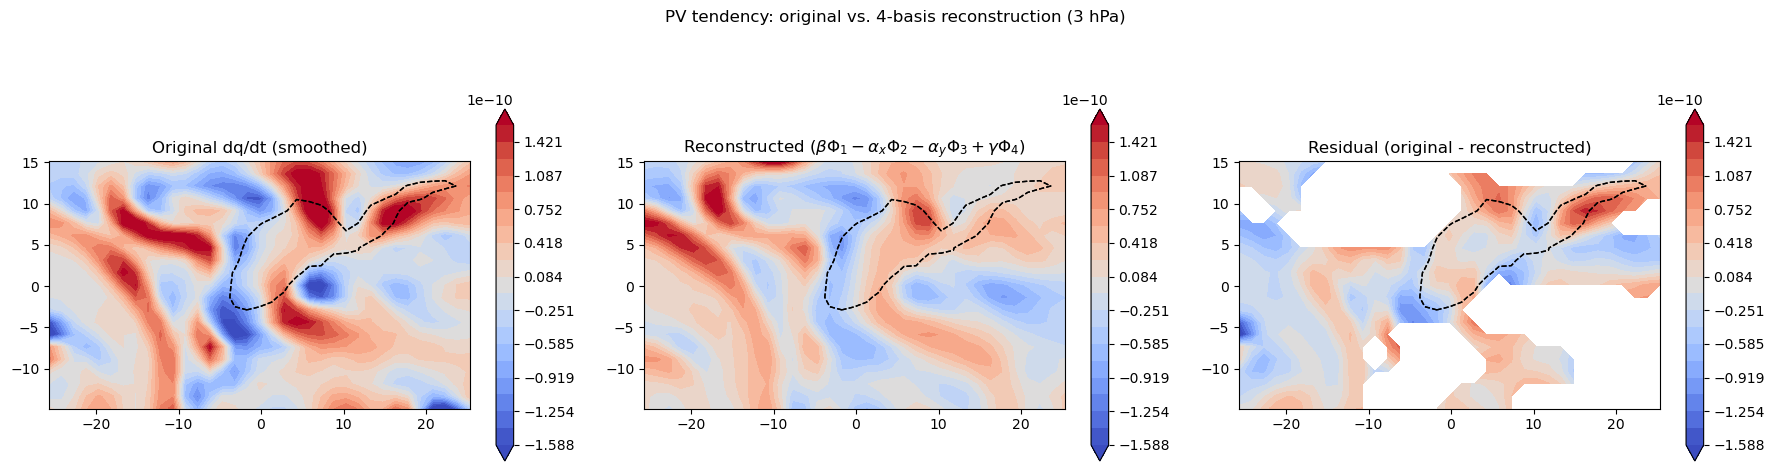

In [11]:
recon = proj["recon"]
resid = proj["resid"]

vmax = np.nanpercentile(np.abs(pv_dt_smooth), 95)
levels_cf = np.linspace(-vmax, vmax, 20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cf0 = axes[0].contourf(x_rel, y_rel, pv_dt_smooth,
                        levels=levels_cf, cmap="coolwarm", extend="both")
contour_enclosing_center(axes[0], x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                         color="k", linewidth=1.0, linestyle="--")
axes[0].set_title("Original dq/dt (smoothed)")
axes[0].set_aspect("equal")
plt.colorbar(cf0, ax=axes[0], shrink=0.8)

cf1 = axes[1].contourf(x_rel, y_rel, recon,
                        levels=levels_cf, cmap="coolwarm", extend="both")
contour_enclosing_center(axes[1], x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                         color="k", linewidth=1.0, linestyle="--")
axes[1].set_title(r"Reconstructed ($\beta\Phi_1 - \alpha_x\Phi_2 - \alpha_y\Phi_3 - \gamma_1\Phi_4 - \gamma_2\Phi_5 + \sigma\Phi_6$)")
axes[1].set_aspect("equal")
plt.colorbar(cf1, ax=axes[1], shrink=0.8)

cf2 = axes[2].contourf(x_rel, y_rel, resid,
                        levels=levels_cf, cmap="coolwarm", extend="both")
contour_enclosing_center(axes[2], x_rel, y_rel, pv_anom_0, PV_CONTOUR_LEVEL,
                         color="k", linewidth=1.0, linestyle="--")
axes[2].set_title("Residual (original - reconstructed)")
axes[2].set_aspect("equal")
plt.colorbar(cf2, ax=axes[2], shrink=0.8)

print(f"Level: {LEVEL_PA/100:.0f} hPa -- single-level PV decomposition")
print(f"\nReconstruction quality:")
print(f"  RMSE              = {proj['rmse']:.3e}")
print(f"  RMSE / max|dq/dt| = {proj['rmse'] / (np.nanmax(np.abs(pv_dt_smooth)) + 1e-30):.3f}")
valid = np.isfinite(pv_dt_smooth) & np.isfinite(recon)
if valid.sum() > 2:
    print(f"  Correlation       = {np.corrcoef(pv_dt_smooth[valid], recon[valid])[0,1]:.4f}")

fig.suptitle(f"PV tendency: original vs. 6-basis reconstruction ({LEVEL_PA/100:.0f} hPa)", y=1.02)
fig.tight_layout()
plt.show()

## 6  Lifecycle time curves (full track)

In [ ]:
# Loop over all valid timesteps (skip first & last for centred diff)
coefs = {k: [] for k in ["beta", "ax", "ay", "gamma1", "gamma2", "sigma"]}
valid_idx = list(range(1, N - 1))  # indices with t-1h and t+1h available

for count, ti in enumerate(valid_idx):
    t_i   = times_hourly[ti]
    ts_i  = pd.Timestamp(t_i)
    clat_i = lats_hourly[ti]
    clon_i = lons_hourly[ti]

    # Storm-following centres for t-1h and t+1h (for tendency centred diff)
    clat_m = lats_hourly[ti - 1]
    clon_m = lons_hourly[ti - 1]
    clat_p = lats_hourly[ti + 1]
    clon_p = lons_hourly[ti + 1]

    # Load PV at t-1h, t, t+1h
    pv_m_2d, lat1d, lon1d = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
    pv_0_2d, _, _         = load_era5_field("pv", t_i)
    pv_p_2d, _, _         = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

    # Climatology at t
    pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)

    # Extract patches -- STORM-FOLLOWING: each offset on its own tracked centre
    pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
    pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_m, clon_m)
    pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_p, clon_p)
    bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

    anom_0 = pv_0_pa - bar_0_pa

    # Gradients at t (no FLIP for anticyclone)
    dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)

    # Tendency via pvtend.ddt (no FLIP)
    pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
    dt_raw = ddt(pv_stack, dt_s=3600.0)[1]

    # Build basis from current-time (dh=0) fields
    b = compute_orthogonal_basis(
        anom_0, dx_0, dy_0,
        xr_, yr_, mask="< -2e-7",
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
    )
    # Project smoothed tendency
    dt_sm = gaussian_smooth_nan(dt_raw, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG)
    p = project_field(dt_sm, b)

    for k in coefs:
        coefs[k].append(p[k])

    if count % 5 == 0:
        print(f"  [{count+1}/{len(valid_idx)}]  dh={dh_vals[ti]:+d}  {ts_i}  ax={p['ax']:.1f} m/s")

# Convert to arrays
for k in coefs:
    coefs[k] = np.array(coefs[k])

print(f"\nDone -- {len(valid_idx)} timesteps processed.")

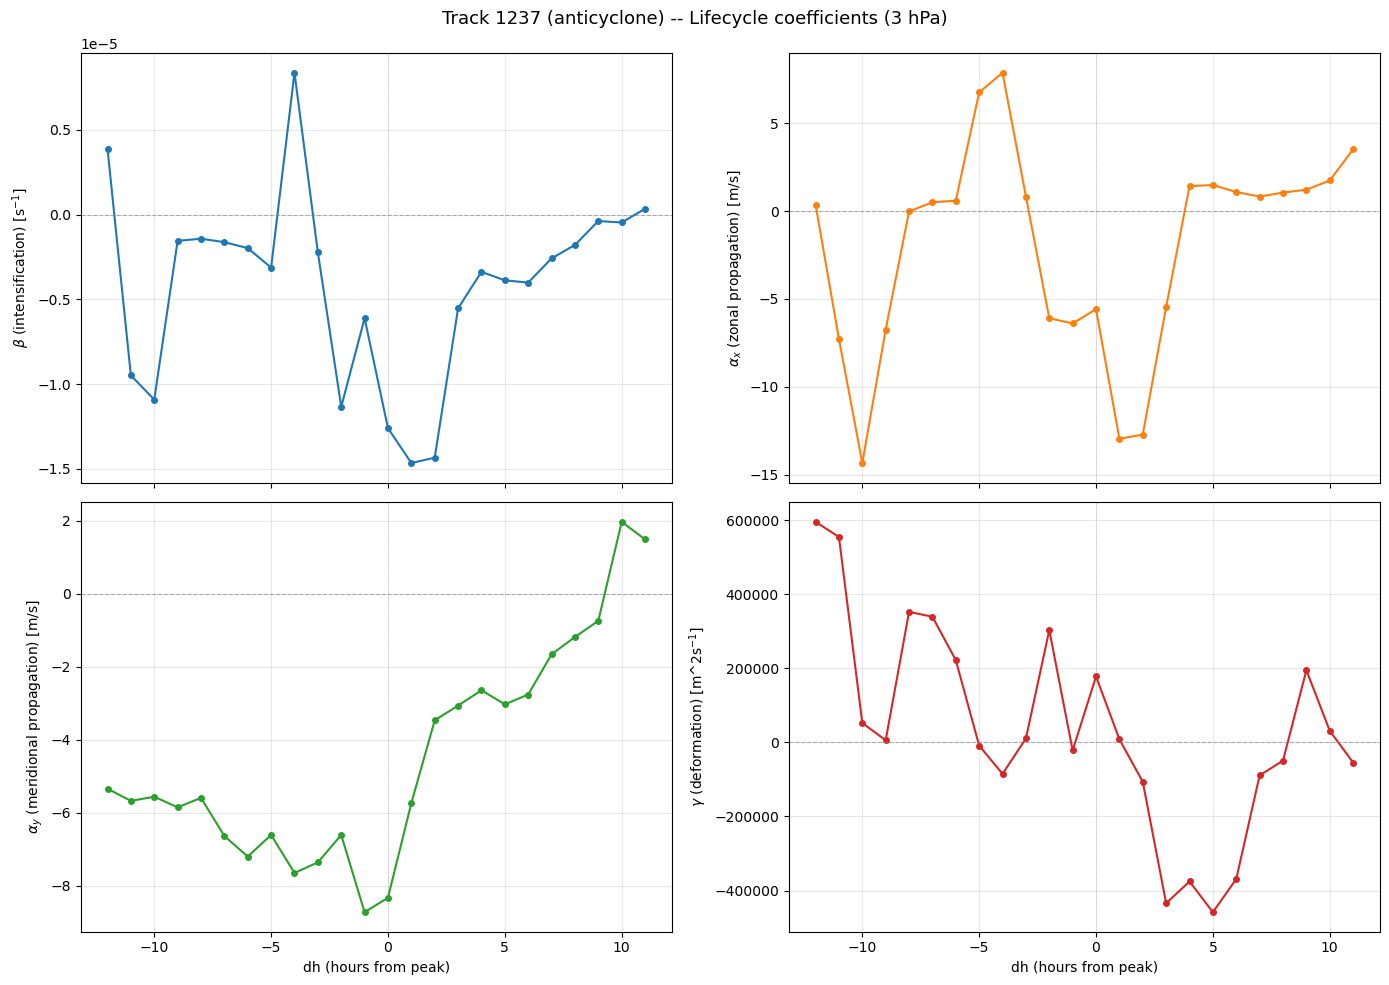

In [13]:
dh_hours = np.array([dh_vals[ti] for ti in valid_idx])
fig = plot_coefficient_curves(
    dh_hours,
    coefs,
    title=f"Track {TRACK_ID} (anticyclone) -- Lifecycle coefficients ({LEVEL_PA/100:.0f} hPa)",
    xlabel="dh (hours from peak)",
)
plt.show()

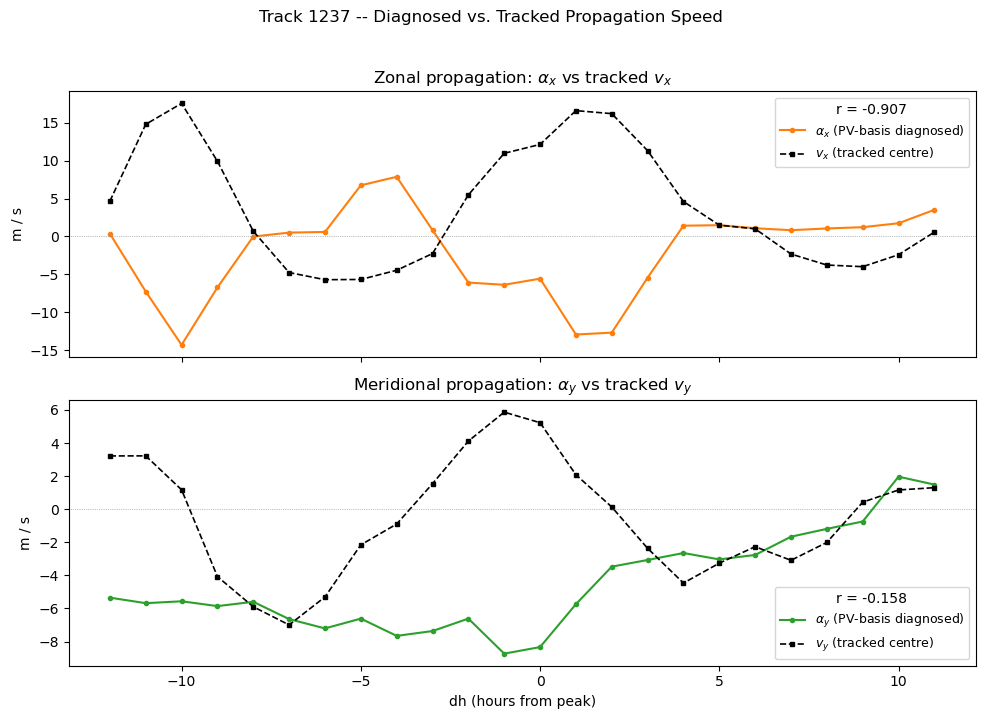

In [14]:
# 2-panel comparison: diagnosed propagation vs tracked speed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

vx_sub = vx_track[1:-1]  # same indices as valid_idx
vy_sub = vy_track[1:-1]

# Zonal
ax1.plot(dh_hours, coefs["ax"], "C1-o", ms=3, lw=1.5,
         label=r"$\alpha_x$ (PV-basis diagnosed)")
ax1.plot(dh_hours, vx_sub, "k--s", ms=3, lw=1.2,
         label=r"$v_x$ (tracked centre)")
ax1.axhline(0, color="grey", lw=0.5, ls=":")
ax1.set_ylabel("m / s")
ax1.set_title(r"Zonal propagation: $\alpha_x$ vs tracked $v_x$")
valid_ax = np.isfinite(coefs["ax"]) & np.isfinite(vx_sub)
if valid_ax.sum() > 2:
    r_ax = np.corrcoef(coefs["ax"][valid_ax], vx_sub[valid_ax])[0, 1]
    ax1.legend(title=f"r = {r_ax:.3f}", fontsize=9)
else:
    ax1.legend(fontsize=9)

# Meridional
ax2.plot(dh_hours, coefs["ay"], "C2-o", ms=3, lw=1.5,
         label=r"$\alpha_y$ (PV-basis diagnosed)")
ax2.plot(dh_hours, vy_sub, "k--s", ms=3, lw=1.2,
         label=r"$v_y$ (tracked centre)")
ax2.axhline(0, color="grey", lw=0.5, ls=":")
ax2.set_xlabel("dh (hours from peak)")
ax2.set_ylabel("m / s")
ax2.set_title(r"Meridional propagation: $\alpha_y$ vs tracked $v_y$")
valid_ay = np.isfinite(coefs["ay"]) & np.isfinite(vy_sub)
if valid_ay.sum() > 2:
    r_ay = np.corrcoef(coefs["ay"][valid_ay], vy_sub[valid_ay])[0, 1]
    ax2.legend(title=f"r = {r_ay:.3f}", fontsize=9)
else:
    ax2.legend(fontsize=9)

fig.suptitle(f"Track {TRACK_ID} -- Diagnosed vs. Tracked Propagation Speed", y=1.02)
fig.tight_layout()
plt.show()

## 7  Cartopy track comparison

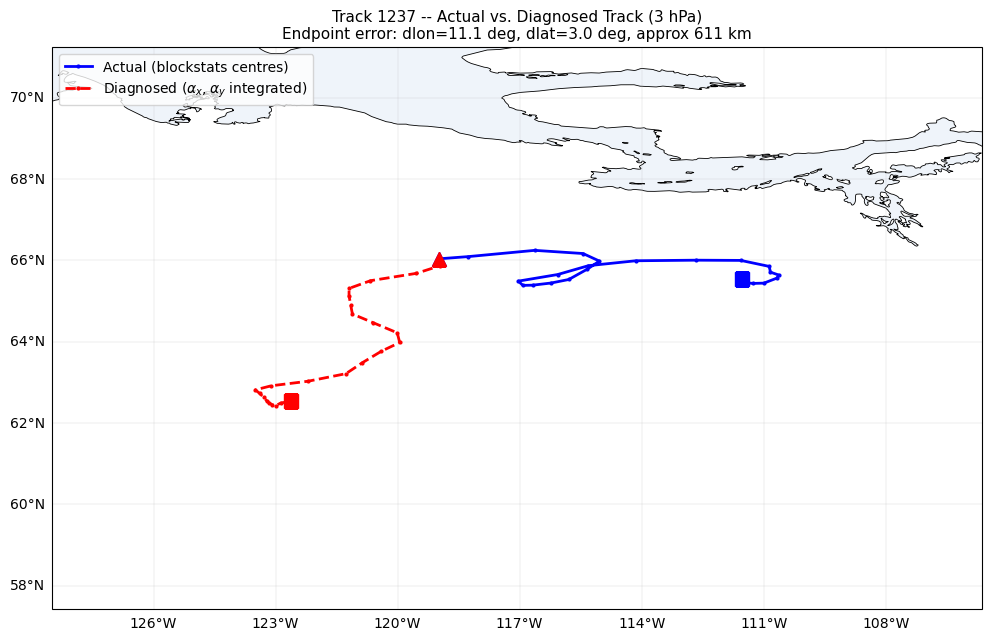

In [15]:
# Time-integrated diagnosed track vs actual blockstats track
# ax, ay are instantaneous at the 15-min basis offset,
# applied over one full hour per timestep.

diag_lon = np.zeros(len(valid_idx) + 1)
diag_lat = np.zeros(len(valid_idx) + 1)
diag_lon[0] = lons_hourly[valid_idx[0]]
diag_lat[0] = lats_hourly[valid_idx[0]]

for i in range(len(valid_idx)):
    lat_r = np.radians(diag_lat[i])
    # ax [m/s] * 3600 s -> metres -> degrees lon
    dlon_deg = coefs["ax"][i] * 3600.0 / (R_EARTH * np.cos(lat_r)) * (180.0 / np.pi)
    # ay [m/s] * 3600 s -> metres -> degrees lat
    dlat_deg = coefs["ay"][i] * 3600.0 / R_EARTH * (180.0 / np.pi)

    if np.isfinite(dlon_deg) and np.isfinite(dlat_deg):
        diag_lon[i+1] = diag_lon[i] + dlon_deg
        diag_lat[i+1] = diag_lat[i] + dlat_deg
    else:
        diag_lon[i+1] = diag_lon[i]
        diag_lat[i+1] = diag_lat[i]

# Actual track (sub-range matching valid_idx)
actual_lon = lons_hourly[valid_idx[0]:valid_idx[-1]+2]
actual_lat = lats_hourly[valid_idx[0]:valid_idx[-1]+2]

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

lon_all = np.concatenate([actual_lon, diag_lon])
lat_all = np.concatenate([actual_lat, diag_lat])
pad = 5
ax.set_extent([lon_all.min()-pad, lon_all.max()+pad,
               lat_all.min()-pad, lat_all.max()+pad],
              crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
ax.add_feature(cfeature.OCEAN, alpha=0.15)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = gl.right_labels = False

# Actual track
ax.plot(actual_lon, actual_lat, "b-o", ms=2, lw=2.0, label="Actual (blockstats centres)",
        transform=ccrs.PlateCarree(), zorder=5)
ax.plot(actual_lon[0], actual_lat[0], "b^", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)
ax.plot(actual_lon[-1], actual_lat[-1], "bs", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)

# Diagnosed track
ax.plot(diag_lon, diag_lat, "r--o", ms=2, lw=2.0,
        label=r"Diagnosed ($\alpha_x, \alpha_y$ integrated)",
        transform=ccrs.PlateCarree(), zorder=5)
ax.plot(diag_lon[0], diag_lat[0], "r^", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)
ax.plot(diag_lon[-1], diag_lat[-1], "rs", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)

# Final displacement error
d_lon = actual_lon[-1] - diag_lon[-1]
d_lat = actual_lat[-1] - diag_lat[-1]
d_km = np.sqrt((d_lon * np.cos(np.radians(actual_lat[-1])) * 111.1)**2
               + (d_lat * 111.1)**2)
ax.set_title(f"Track {TRACK_ID} -- Actual vs. Diagnosed Track ({LEVEL_PA/100:.0f} hPa)\n"
             f"Endpoint error: dlon={d_lon:.1f} deg, dlat={d_lat:.1f} deg, "
             f"approx {d_km:.0f} km", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
plt.show()

In [ ]:
# Animated GIF: PV tracking (cartopy) + basis decomposition
# Pre-load frame data for all valid timesteps
frames_data = {}

for count, ti in enumerate(valid_idx):
    t_i   = times_hourly[ti]
    ts_i  = pd.Timestamp(t_i)
    clat_i = lats_hourly[ti]
    clon_i = lons_hourly[ti]

    clat_m = lats_hourly[ti - 1]
    clon_m = lons_hourly[ti - 1]
    clat_p = lats_hourly[ti + 1]
    clon_p = lons_hourly[ti + 1]

    pv_0_2d, lat1d, lon1d = load_era5_field("pv", t_i)
    pv_m_2d, _, _ = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
    pv_p_2d, _, _ = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

    pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)

    pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
    pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_m, clon_m)
    pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_p, clon_p)
    bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

    anom_0 = pv_0_pa - bar_0_pa

    dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)

    b = compute_orthogonal_basis(
        anom_0, dx_0, dy_0,
        xr_, yr_, mask="< -2e-7",
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
    )
    pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
    dt_raw = ddt(pv_stack, dt_s=3600.0)[1]
    dt_sm = gaussian_smooth_nan(dt_raw, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG)
    p = project_field(dt_sm, b)

    frames_data[count] = {
        "pv_total": pv_0_pa,
        "pv_anom": anom_0,
        "center_lat": clat_i,
        "center_lon": clon_i,
        "lat_vec": lat_s,
        "lon_vec": lon_s,
        "basis": b,
        "proj": p,
        "x_rel": xr_,
        "y_rel": yr_,
    }

frame_ids = sorted(frames_data.keys())
gif_frames = frame_ids
print(f"Loaded {len(frame_ids)} frames, using all {len(gif_frames)} for hourly GIF")

# Precompute colour limits
all_pv = np.concatenate([frames_data[f]["pv_total"].ravel() for f in gif_frames])
pv_vmin, pv_vmax = np.nanpercentile(all_pv, [2, 98])

coef_keys = ["beta", "ax", "ay", "gamma1", "gamma2", "sigma"]
field_signs = [1.0, -1.0, -1.0, -1.0, -1.0, 1.0]

coef_labels_units = [
    r"$\beta$ [s$^{-1}$]",
    r"$\alpha_x$ [m s$^{-1}$]",
    r"$\alpha_y$ [m s$^{-1}$]",
    r"$\gamma_1$ [m$^2$ s$^{-1}$]",
    r"$\gamma_2$ [m$^2$ s$^{-1}$]",
    r"$\sigma$ [m$^2$ s$^{-1}$]",
]
coef_colors = ["C0", "C1", "C2", "C3", "C4", "C5"]
phi_names = ["phi_int", "phi_dx", "phi_dy", "phi_def", "phi_strain", "phi_lap"]
phi_labels = [r"$\beta \cdot \hat\Phi_1$",
              r"$-\alpha_x \cdot \hat\Phi_2$",
              r"$-\alpha_y \cdot \hat\Phi_3$",
              r"$-\gamma_1 \cdot \hat\Phi_4$",
              r"$-\gamma_2 \cdot \hat\Phi_5$",
              r"$\sigma \cdot \hat\Phi_6$"]

basis_vmax = {}
for ck, pn, sgn in zip(coef_keys, phi_names, field_signs):
    vals = []
    for f in gif_frames:
        fd = frames_data[f]
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck]
        if np.isfinite(c) and phi is not None:
            vals.append(np.nanmax(np.abs(sgn * c * phi)))
    basis_vmax[ck] = np.nanpercentile(vals, 95) if vals else 1.0

# Central projection centred on mid-track
mid_f = gif_frames[len(gif_frames) // 2]
proj_map = ccrs.LambertConformal(
    central_longitude=frames_data[mid_f]["center_lon"],
    central_latitude=frames_data[mid_f]["center_lat"],
)
data_crs = ccrs.PlateCarree()

# Build figure layout
fig = plt.figure(figsize=(22, 16))
fig.subplots_adjust(left=0.04, right=0.98)
outer = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.18)

ax_pv = fig.add_subplot(outer[0], projection=proj_map)

inner = gridspec.GridSpecFromSubplotSpec(6, 2, subplot_spec=outer[1],
                                          hspace=0.45, wspace=0.35)
ax_1d = [fig.add_subplot(inner[i, 0]) for i in range(6)]
ax_2d = [fig.add_subplot(inner[i, 1]) for i in range(6)]

# Helper to draw PV map
def draw_pv_map(ax_map, fidx, frame_pos):
    fd = frames_data[fidx]
    lon2d, lat2d = np.meshgrid(fd["lon_vec"], fd["lat_vec"])

    ax_map.set_extent([fd["lon_vec"].min()-5, fd["lon_vec"].max()+5,
                       fd["lat_vec"].min()-5, fd["lat_vec"].max()+5],
                      crs=data_crs)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
                     x_inline=False, y_inline=False)

    cf = ax_map.contourf(lon2d, lat2d, fd["pv_total"], levels=30,
                          cmap="YlGnBu", vmin=pv_vmin, vmax=pv_vmax,
                          transform=data_crs)

    # PV anom contour (negative for anticyclone) -- centre-enclosing only
    contour_enclosing_center(ax_map, lon2d, lat2d, fd["pv_anom"], PV_CONTOUR_LEVEL,
                             center=(fd["center_lon"], fd["center_lat"]),
                             color="k", linewidth=1.5, linestyle="-",
                             transform=data_crs)

    # Past track trajectory
    past = [f for f in gif_frames[:frame_pos + 1]]
    if past:
        tl = [frames_data[f]["center_lon"] for f in past]
        tt = [frames_data[f]["center_lat"] for f in past]
        ax_map.plot(tl, tt, "r-", lw=2, transform=data_crs, zorder=5)
        ax_map.plot(tl[-1], tt[-1], "ro", ms=8, transform=data_crs, zorder=6)
        if len(tl) > 1:
            ax_map.plot(tl[0], tt[0], "r^", ms=7, transform=data_crs, zorder=6)

    ti_actual = valid_idx[fidx]
    ax_map.set_title(f"PV @ {LEVEL_PA/100:.0f} hPa  |  dh={dh_vals[ti_actual]:+d}  "
                     f"{pd.Timestamp(times_hourly[ti_actual])}", fontsize=11)
    return cf

# Helper to draw 2D basis panels
def draw_2d_panels(fidx):
    fd = frames_data[fidx]
    Xr_f, Yr_f = np.meshgrid(fd["x_rel"], fd["y_rel"])
    for i, (ck, pn, lab, sgn) in enumerate(zip(coef_keys, phi_names, phi_labels, field_signs)):
        ax_2d[i].cla()
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck] if np.isfinite(fd["proj"][ck]) else 0.0
        fld = sgn * c * phi
        vm = basis_vmax[ck]
        ax_2d[i].pcolormesh(Xr_f, Yr_f, fld, cmap="RdBu_r",
                             vmin=-vm, vmax=vm, shading="auto")
        contour_enclosing_center(ax_2d[i], Xr_f, Yr_f, fd["pv_anom"],
                                 PV_CONTOUR_LEVEL, color="k", linewidth=1.8,
                                 linestyle="-", alpha=0.45)
        ax_2d[i].set_aspect("equal")
        ax_2d[i].set_title(lab, fontsize=9)
        if i == 3:
            ax_2d[i].set_xlabel("dlon (deg)")

# Draw first frame
f0 = gif_frames[0]
fd0 = frames_data[f0]
cf_pv = draw_pv_map(ax_pv, f0, 0)
cb_pv = fig.colorbar(cf_pv, ax=ax_pv, label="PV (PVU)", shrink=0.75, pad=0.02)

# 1D curves over full lifecycle
markers_1d = []
life_hours = dh_hours
for i, (ck, lab_u, col) in enumerate(zip(coef_keys, coef_labels_units, coef_colors)):
    ax_1d[i].plot(life_hours, coefs[ck], color=col, lw=1.5)
    ax_1d[i].axhline(0, color="grey", lw=0.4, ls=":")
    m, = ax_1d[i].plot(life_hours[f0], coefs[ck][f0], "o", color=col, ms=8, zorder=5)
    markers_1d.append(m)
    ax_1d[i].set_ylabel(lab_u, fontsize=9)
    if i == 3:
        ax_1d[i].set_xlabel("dh (hours from peak)")

# Initial 2D panels
draw_2d_panels(f0)

fig.suptitle(f"Track {TRACK_ID} (anticyclone) -- PV lifecycle + basis decomposition "
             f"({LEVEL_PA/100:.0f} hPa)", fontsize=13, y=0.98)

# Animation update
def update(frame_pos):
    fidx = gif_frames[frame_pos]
    fd = frames_data[fidx]

    ax_pv.cla()
    draw_pv_map(ax_pv, fidx, frame_pos)

    for i, ck in enumerate(coef_keys):
        markers_1d[i].set_data([life_hours[fidx]], [coefs[ck][fidx]])

    draw_2d_panels(fidx)
    return []

anim = FuncAnimation(fig, update, frames=len(gif_frames),
                      interval=200, blit=False)
anim.save(GIF_PATH, writer=PillowWriter(fps=5))
plt.close(fig)

print(f"Saved GIF -> {GIF_PATH}")
IPImage(filename=GIF_PATH)

## 8  Budget closure — RHS term coefficients

In [ ]:
# Budget closure requires U, V fields at 300 hPa
# Check a sample ERA5 U/V file exists
sample_ts = pd.Timestamp(times_hourly[1])
u_file = f"{ERA_DIR}/era5_u_{sample_ts.year}_{sample_ts.month:02d}.nc"
v_file = f"{ERA_DIR}/era5_v_{sample_ts.year}_{sample_ts.month:02d}.nc"

if not (os.path.exists(u_file) and os.path.exists(v_file)):
    print(f"ERA5 U/V files not found for track period -- skipping budget closure.")
    print(f"  Checked: {u_file}")
    budget_ok = False
else:
    budget_ok = True
    TERM_NAMES_C = [
        "dq/dt",
        r"$-\bar{u}\,q'_x$",
        r"$-\bar{v}\,q'_y$",
        r"$-u'\,\bar{q}_x$",
        r"$-v'\,\bar{q}_y$",
        r"$\Sigma$",
    ]
    term_coefs_c = {name: {k: [] for k in ["beta","ax","ay","gamma1","gamma2","sigma"]}
                    for name in TERM_NAMES_C}

    smooth_fn = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG,
                                               grid_spacing=GRID_DEG)

    for count, ti in enumerate(valid_idx):
        t_i   = times_hourly[ti]
        ts_i  = pd.Timestamp(t_i)
        clat_i = lats_hourly[ti]
        clon_i = lons_hourly[ti]

        clat_m = lats_hourly[ti - 1]
        clon_m = lons_hourly[ti - 1]
        clat_p = lats_hourly[ti + 1]
        clon_p = lons_hourly[ti + 1]

        # PV fields
        pv_0_2d, lat1d, lon1d = load_era5_field("pv", t_i)
        pv_m_2d, _, _         = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
        pv_p_2d, _, _         = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

        pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)

        # U, V at t (on t's centre -- instantaneous advection)
        u_2d, _, _ = load_era5_field("u", t_i)
        v_2d, _, _ = load_era5_field("v", t_i)
        u_bar = load_clim_field("u", ts_i.month, ts_i.day, ts_i.hour)
        v_bar = load_clim_field("v", ts_i.month, ts_i.day, ts_i.hour)

        # Extract patches -- STORM-FOLLOWING for PV offsets
        pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
        pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_m, clon_m)
        pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_p, clon_p)
        bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

        # U, V on t's centre
        u_pa, *_    = extract_patch(u_2d,   lat1d, lon1d, clat_i, clon_i)
        v_pa, *_    = extract_patch(v_2d,   lat1d, lon1d, clat_i, clon_i)
        ub_pa, *_   = extract_patch(u_bar,  lat1d, lon1d, clat_i, clon_i)
        vb_pa, *_   = extract_patch(v_bar,  lat1d, lon1d, clat_i, clon_i)

        anom_0 = pv_0_pa - bar_0_pa
        u_anom = u_pa - ub_pa
        v_anom = v_pa - vb_pa

        # Gradients at t (no FLIP for anticyclone)
        dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)
        bar_dx, bar_dy = compute_gradients(bar_0_pa, lat_s, xr_, yr_)

        # Tendency via pvtend.ddt (no FLIP)
        pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
        dt_raw = ddt(pv_stack, dt_s=3600.0)[1]

        # Basis from current-time fields
        b = compute_orthogonal_basis(
            anom_0, dx_0, dy_0, xr_, yr_,
            mask="< -2e-7", apply_smoothing=True,
            smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
        )

        def proj_term(field_2d):
            return project_field(smooth_fn(field_2d), b)

        # dq/dt
        p = proj_term(dt_raw)
        for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
            term_coefs_c["dq/dt"][k].append(p[k])

        # Individual RHS terms (no FLIP)
        rhs = [
            (r"$-\bar{u}\,q'_x$",  -ub_pa * dx_0),
            (r"$-\bar{v}\,q'_y$",  -vb_pa * dy_0),
            (r"$-u'\,\bar{q}_x$",  -u_anom * bar_dx),
            (r"$-v'\,\bar{q}_y$",  -v_anom * bar_dy),
        ]
        closure = np.zeros_like(pv_0_pa)
        for name, fld in rhs:
            p = proj_term(fld)
            for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
                term_coefs_c[name][k].append(p[k])
            closure += fld

        p = proj_term(closure)
        for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
            term_coefs_c[r"$\Sigma$"][k].append(p[k])

        if count % 5 == 0:
            print(f"  Budget [{count+1}/{len(valid_idx)}]  dh={dh_vals[ti]:+d}")

    # Convert to arrays
    for name in TERM_NAMES_C:
        for k in term_coefs_c[name]:
            term_coefs_c[name][k] = np.array(term_coefs_c[name][k])

    print("Budget projection done.")

In [ ]:
# 4-panel budget decomposition curves
if budget_ok:
    fig = plt.figure(figsize=(22, 14))
    gs = fig.add_gridspec(3, 3, width_ratios=[1, 1, 0.35], wspace=0.35, hspace=0.3)

    ax_panels = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[2, 0]),,
        fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 1]),,
    ]
    ax_legend = fig.add_subplot(gs[:, 2])
    ax_legend.axis("off")

    coef_info = [
        ("beta",  r"$\beta$ (intensification)",     r"s$^{-1}$"),
        ("ax",    r"$\alpha_x$ (zonal propagation)", "m/s"),
        ("ay",    r"$\alpha_y$ (merid. propagation)","m/s"),
        ("gamma1", r"$\gamma_1$ (shear def.)",       r"m$^2$ s$^{-1}$"),
    ("gamma2", r"$\gamma_2$ (strain def.)",      r"m$^2$ s$^{-1}$"),
    ("sigma",  r"$\sigma$ (Laplacian)",          r"m$^2$ s$^{-1}$"),
    ]

    tab_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    term_style_c = {
        "dq/dt":                  dict(color="k",           lw=2.5, ls="-",  zorder=10),
        r"$\Sigma$":              dict(color="k",           lw=2.0, ls="--", zorder=9),
        r"$-\bar{u}\,q'_x$":     dict(color=tab_colors[0], lw=1.5, ls="-"),
        r"$-\bar{v}\,q'_y$":     dict(color=tab_colors[1], lw=1.5, ls="-"),
        r"$-u'\,\bar{q}_x$":     dict(color=tab_colors[2], lw=1.5, ls="-"),
        r"$-v'\,\bar{q}_y$":     dict(color=tab_colors[3], lw=1.5, ls="-"),
    }

    handles_all = []
    for ax_p, (key, title, unit) in zip(ax_panels, coef_info):
        for name in TERM_NAMES_C:
            st = term_style_c[name]
            h, = ax_p.plot(dh_hours, term_coefs_c[name][key], label=name, **st)
            if ax_p is ax_panels[0]:
                handles_all.append(h)
        ax_p.axhline(0, color="gray", lw=0.5, ls=":")
        ax_p.set_title(title)
        ax_p.set_ylabel(unit)

    ax_panels[4].set_xlabel("dh (hours from peak)")
    ax_panels[5].set_xlabel("dh (hours from peak)")

    ax_legend.legend(handles_all, TERM_NAMES_C, loc="center", fontsize=10,
                     frameon=True, framealpha=0.9, edgecolor="gray")

    fig.suptitle(f"Track {TRACK_ID} -- Budget decomposition "
                 f"({LEVEL_PA/100:.0f} hPa, horizontal advection)", y=1.02)
    plt.show()
else:
    print("Budget closure was skipped (U/V data not available).")

## Summary

- **`compute_orthogonal_basis`** builds the six Gram-Schmidt-orthogonalised
  basis fields (Phi1...Phi4) from the PV anomaly and its spatial gradients.
- **`project_field`** decomposes any 2-D field (e.g. dq/dt) into
  intensification (β), propagation (αx, αy), shear (γ₁), strain (γ₂), and Laplacian (σ) coefficients.
- PV anomaly at 300 hPa is **naturally negative** for anticyclones — **no FLIP needed**.
  `mask="< -2e-7"` directly isolates the anticyclone interior.
- Basis constructed from **current-time (dh=0)** anomaly, gradients, and mask — **no temporal interpolation**.
- The **Cartopy track comparison** shows actual NPZ-derived centres vs. the track
  obtained by time-integrating (ax, ay) × 1 h per step.
- Budget closure decomposes propagation drivers into mean-wind advection
  of the anomaly vs. anomaly advection of the mean PV gradient.